
**DIAMOND A-DC PBSHM Coding Challenge**

---

- **Name**: Ernest Toochukwu, Samuel
- **Date**: 02-04-2026

---
## Population-Based Structural Health Monitoring (PBSHM)

### Objective
Detect whether a structure is damaged using measurement-like features and graph structure.

## Dataset Overview
- 50 structures
- Each has 4–8 storeys
- Structure Features:
  - Structure id (`structure_id`)
  - Number of Storeys (`n_storeys`)
  - Edges (`edges`)
  - Node Features (`n_features`)
  - Feature Names (`feature_names`)

- Node features:
  - Storey (`storey`)
  - height (`height_m`)
  - dominant modal frequency (`dominant_modal_frequency_Hz`)

- Available Structure Labels:
  - Structure id (`structure_id`)
  - Damaged (`damaged`)
  - Damage Storey (`damage_storey`)
  ---
  

# **Libraries and Tasks environment setting up**

In [60]:
# Install Torch Geometric Library
# %%capture
# !pip install torch_geometric

In [61]:
# # Uncomment if you are running on Google Colab and need to mount your Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# **Task1: Population Exploration (EDA)**

**Objectives:**

- Visualize the distribution of structure sizes and geometry
- Explore the starter population graph
- Inspect the provided measurement-like node features
- Propose which raw or derived features might be damage-sensitive

In [62]:
%%capture

# Run to capture Task1, Functions
%run task1_explore_population.ipynb


## **Visualize the distribution of structure sizes and geometry**
- Values and funtions from `task1_explore_population.ipynb`

---

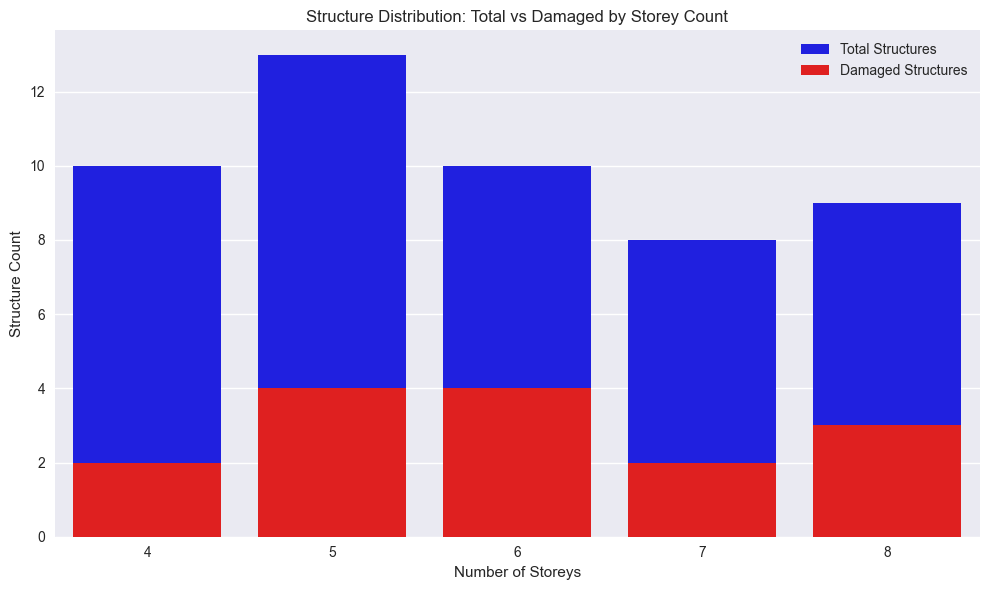

In [63]:
plot_structure_distribution(structure_df)

**Distribution of structure sizes and geometry Insights**

---

- ***Structure Size Distribution***: The plot shows a right-skewed distribution for the number of storeys, with a higher prevalence of shorter buildings (e.g., 4-5 storeys) than taller buildings (e.g., 7-8 storeys).

- ***Damage Distribution***: The proportion of damaged structures (red bars) relative to the total structures (blue bars) appears to be consistent across different storey counts. This suggests that damage is not preferentially concentrated in structures of a particular size.

---


### **Structure Graph Visualization**

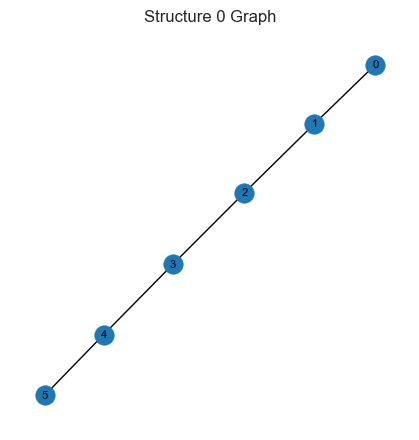

In [64]:

structure_index = 0 # Select Structure

plot_structure_graph(structure_collection, structure_index) # Visualize Selected structure

 **Structure Graph Insights**

---
*   The graph for `structure_id=0` (and similar individual structure graphs) clearly shows a linear chain of nodes (storeys) connected by edges. This visual representation matches the expected 'shear frame' model where each storey is connected to its adjacent storeys.

*   The nodes are labeled with their storey numbers, providing a clear mapping of the structure's vertical configuration.

---

### **Population Graph Visualization**

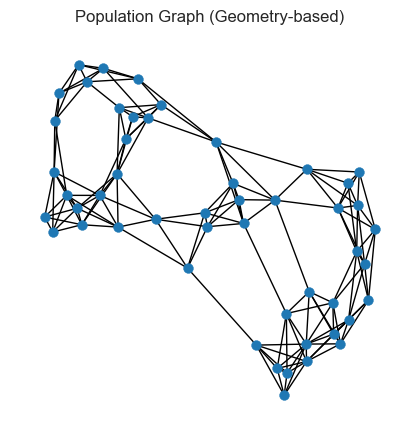

In [65]:
plot_population_graph(edges)

**Population Graph Insights**

---

*   The population graph, composed of 50 nodes (representing 50 structures), displays a highly interconnected network. This suggests that many structures share similar geometric properties, leading to numerous connections based on the 'geometry-based' edges.

*   The dense clustering in the graph indicates a high degree of similarity among structures within the population, which can be useful for population-based damage detection methods.

---

## **Inspection of node features measurement**
- Values and funtions from `task1_explore_population.ipynb`

---

In [66]:
# Including drived features
nodes_df.describe()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey,dominant_modal_frequency_Hz_squared,inverse_height_cubed,frequency_times_height,abs_dominant_modal_frequency_Hz_squared_diff,local_dominant_modal_frequency_Hz_squared_dev,local_frequency_times_height_dev
count,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,90.000000,293.000000,293.000000,293.000000,243.000000,293.000000,293.000000
mean,2.593857,3.947676,4.396528,24.627986,6.187713,0.307167,2.211111,24.280030,0.018532,17.362917,21.134108,14.712654,6.968214
std,1.937967,0.588043,2.228794,14.563565,1.383211,0.462109,1.757772,19.419544,0.008088,9.330617,16.581435,9.573477,4.740503
min,0.000000,3.002000,0.600270,0.000000,4.000000,0.000000,0.000000,0.360324,0.008048,1.986293,0.000000,0.223296,0.059187
25%,1.000000,3.414000,2.586980,12.000000,5.000000,0.000000,0.000000,6.692466,0.011047,9.688240,7.667665,6.046130,3.141302
50%,2.000000,3.869000,4.495740,25.000000,6.000000,0.000000,2.500000,20.211678,0.017266,17.446236,19.842930,14.024745,6.358893
75%,4.000000,4.490000,6.526510,38.000000,7.000000,1.000000,4.000000,42.595333,0.025131,24.129783,31.740664,21.052212,9.669192
max,7.000000,4.990000,8.545530,49.000000,8.000000,1.000000,5.000000,73.026083,0.036963,41.633822,67.664496,47.023486,22.381663


**Node level measurement insight**

---

- The frequency standared deviation accross nodes is more significant (2.229) compaied to the local heights (0.588).

- Min-Max different in height is also low (1.988) compaired to the dominant frequency (7.945)

In each case, frequency show more informative power. number of node vs total height of each storey is also inspected in the `task1_explore_population.ipynb` it showed to be consistent with each other.

---


### **Inspection of node feature Correlations**

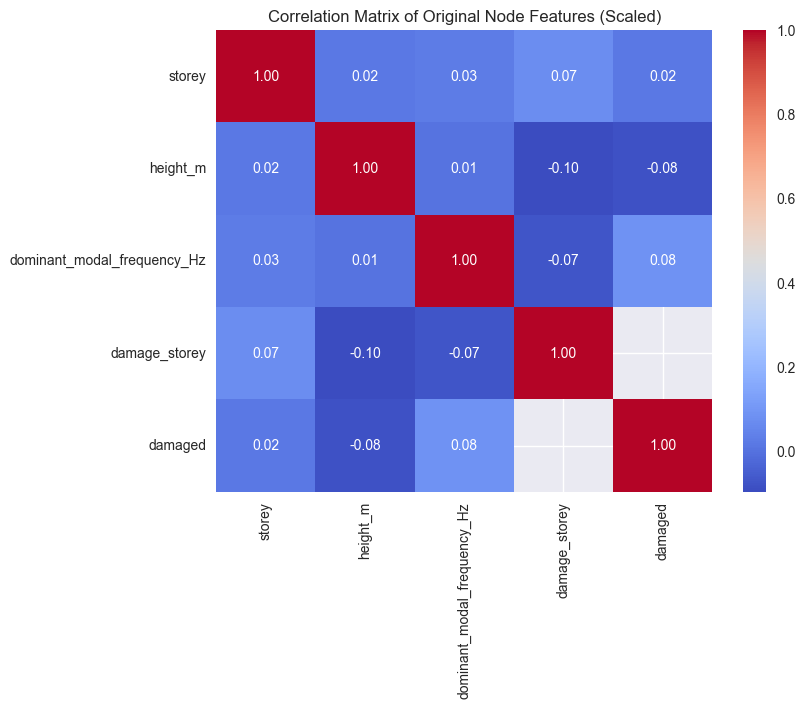

In [67]:
correlation_matrix_nodes = nodes_df[node_feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_nodes, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Original Node Features (Scaled)")
plt.show()

 **Node features correlation insight**

 ---

- Raw frequency or height alone is not sufficient as the are statisticaly weak (r=0.08 and  r=-0.08 respectively) but it remains informative. In node level damage (`damaged_storey`), height showed more signal strenght (r=-0.10) though still very weak.
---

### **Node Feature Engineering Motivation**

The fundamental relationship governing structural dynamics is:

$ [
\omega \propto \sqrt{\frac{K}{M}}
] $

where $ ( \omega ) $ is the natural frequency, $ ( K ) $ is stiffness, and $ ( M ) $is mass.  
Structural damage reduces stiffness locally, producing deviations in frequency across adjacent storeys.

---


| Feature | Formula | Physics Meaning | Why it helps |
|---|---|---|---|
| Measured Stiffness Proxy | $\omega^2$ | Dynamic Response | Tells the model how the building actually behaves based on its vibration data. |
| Theoretical Stiffness Proxy | $1/h^3$ | Geometric Constraint | Tells the model what the stiffness should be for a structure of that specific height. |
| Material Property Proxy | $\omega \cdot h$ | Shear Wave Velocity ($V_s$) | Relates to the speed of wave propagation, identifying the building material (e.g., steel vs. concrete) regardless of height. |

---

***Motivation References***

* Chopra, A. K. (2017). Dynamics of Structures: Theory and Applications to Earthquake Engineering. Pearson. (Fundamental relationship of $k = \omega^2 m$ and shear frame stiffness $k = 12EI/h^3$).
* Kramer, S. L. (1996). Geotechnical Earthquake Engineering. Prentice Hall. (Relation between frequency, height, and shear wave velocity $V_s \approx 4h \cdot f$).

---



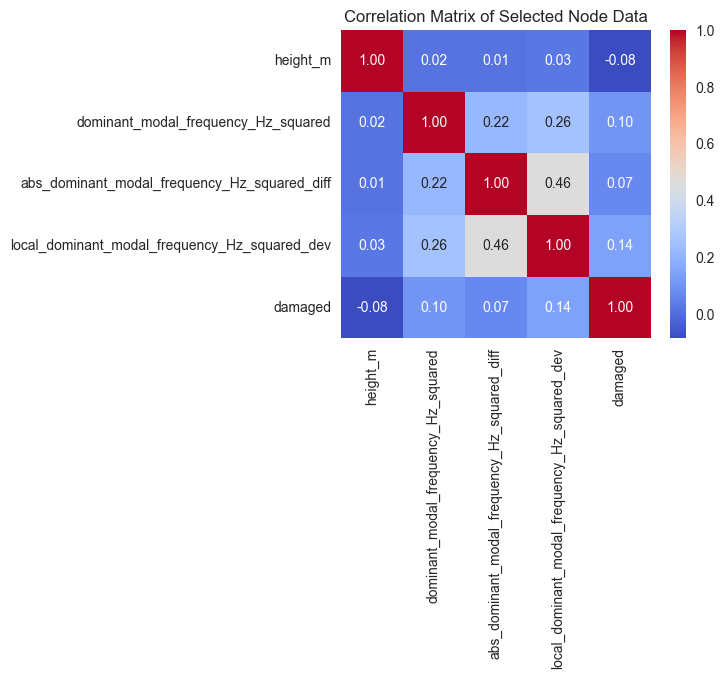

In [68]:
# Inspect Selected Drived Feature Nodes Correlation

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix_nodes_engineered, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Selected Node Data")
plt.show()

**Selected node level data insignt**

---

- Improvements in feature information was observed for Frequency signal (r=0.10 and 0.14)

- General correlation plot can be found in `task1_explore_population.ipynb`

---

The following node-level features are selected from the correlation analysis, ranked by their statistical significance relative to the damaged state:

| Feature | Correlation ($r$) | Physical Justification |
|---|---|---|
| $\text{Local Frequency }^2 Deviation$ | $0.14$ | Measures localized stiffness variance relative to adjacent nodes; strongest indicator of nodal-level anomalies. |
| $\text{Dominant Modal Frequency}^2$ | $0.10$ | Direct proxy for nodal stiffness ($k \propto \omega^2$); fundamental indicator of structural integrity at the point of measurement. |
| $\text{Absolute Frequency }^2 Difference$ | $0.07$ | Captures the magnitude of frequency shifts between sequential nodes; highlights discontinuities in the load path. |
| $ \text{Node Height ($h$) }$| $-0.08$ | Minimal correlation; indicates that damage occurrence is independent of vertical nodal position within the shear-frame. |
---

**Nodel level Summary of Findings**

At the node level:
- $\text{Local Frequency }^2 Deviation$ is the most significant variable for damage detection.

- The dynamic features consistently outperform geometric features ($h$), confirming that localized shifts in frequency response provide a more robust signal for structural health monitoring than absolute spatial coordinates.

---


### **Structure level Feature inspection**

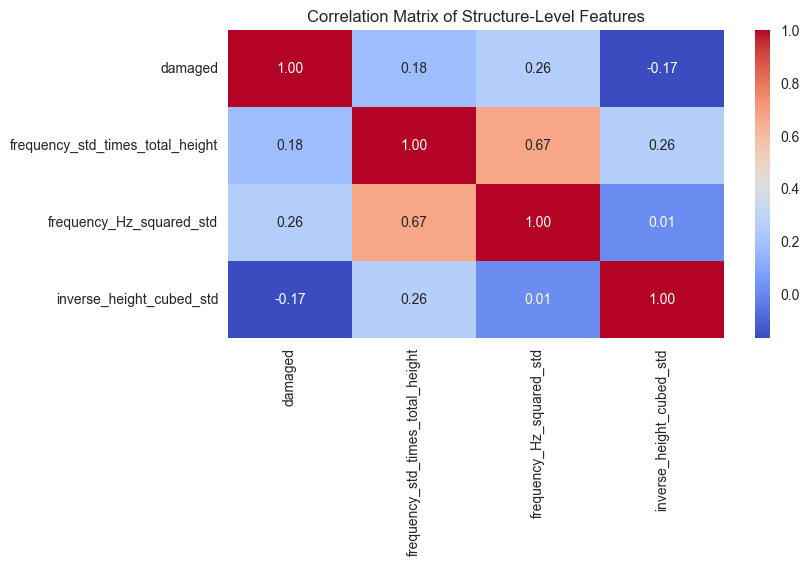

In [69]:
# Compute the correlation matrix without 'structure_id' as it is an identifier

# Plot the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(selected_structure_correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Structure-Level Features")
plt.show()

Key Observations and Insights

* **Frequency as a Damage Indicator**: The frequency-based signals, specifically the squared frequency (frequency_Hz_squared_std), show the highest correlation with the damaged state ($0.26$). This confirms that **frequency is the most damage-sensitive** signal, as any loss in structural integrity (stiffness) directly manifests as a shift in the natural frequency.


* **Significance of Structural Level over Node Level**: A key observation is that both local height variance and frequency variance are significantly more informative at the structure level than at the individual node level. These sugests that aggregating these signals allows the model to capture global structural behavior (like inter-story drift or total shear-frame response) that is lost when looking at nodes in isolation.

* **Signal Strength in Sparse Correlations**: While the raw correlation coefficients may appear relatively low (ranging from $0.17$ to $0.26$), they remain significant indicators for this structural analysis. In the context of engineering data, predictive power may be poor due to limitation in data quantity and quality.

------------------------------


## **Population summary**

------------------------------
- ***Frequency derivatives are observed to show the most damage-sensitive.***

The following three derived features are proposed as damage-sensitive features to represent the physical and dynamic characteristics of the building at a global scale:

| Feature | Physical Approximation | Model Input Name |
|---|---|---|
| Measured Stiffness Variance | $\omega^2$ (Standard Deviation) | frequency_Hz_squared_std |
| Material Property Variance | $\omega \cdot H$ ($\omega$ Standard Deviation) | frequency_std_times_total_height |
| Geometric Stiffness Variance | $1/h^3$ (Standard Deviation) | inverse_height_cubed_std |

------------------------------

# **Task 2 - Simple structure-level baseline**

---
**Objective:**

Build a simple baseline for damage detection using fixed-length summaries of each structure.

---
Models explored:

- Random forest
- logistic regression

---
Detailed code can be found: `task2_structure_bl_model.ipynb`

---

In [70]:
%%capture
# Run to capture Task2, Functions
%run task2_structure_bl_model.ipynb

### **Correlation plot of data used for Task2**

In [71]:
## Inspect available funtions and variables
# print(list(globals().keys()))

In [72]:
# Compute the correlation matrix without 'structure_id'
structure_bl_df = structure_df[['structure_id', 'damaged', 'frequency_Hz_squared_std', 'frequency_std_times_total_height']]
# Normalize selected structure features
structure_norm_df = normalize_structure_features(structure_bl_df)
structure_norm_df.head()

,Freq_norm,Height_norm,damaged,structure_id
0,0.861854,0.684679,0,0
1,0.834459,0.313477,0,1
2,0.385878,0.300799,0,2
3,0.929480,0.589334,1,3
4,0.931752,0.770566,1,4


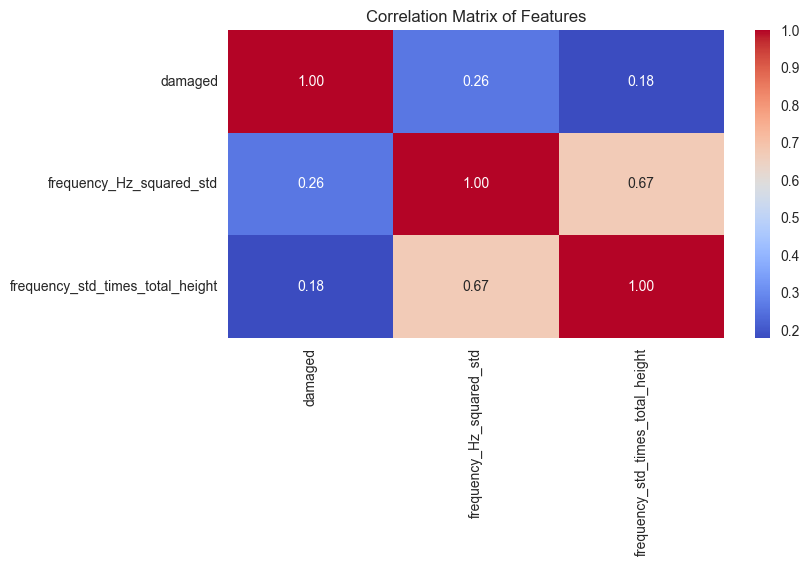

In [73]:
# Compute the correlation matrix without 'structure_id'
correlation_matrix_t2 = structure_bl_df.drop(columns=['structure_id']).corr()

# Plot the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix_t2, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Features")
plt.show()

## **Baseline Models**

### **Random Forest -Baseline Model**

---

In [74]:
# ── Features & Target ─────────────────────────────────────────────
features = structure_norm_df.drop(columns=['structure_id', 'damaged'])
target_damaged = structure_norm_df['damaged']

# ── Random Forest Model ─────────────────────────────────────────────────────────
rf_params = {
    'max_depth': 6,
    'min_samples_leaf': 4,
    'class_weight': 'balanced',
    'random_state': 50
}

best_rf_model, rf_fold_results = run_cv_and_report(
    features,
    target_damaged,
    estimator_class=RandomForestClassifier,
    estimator_params=rf_params,
    n_splits=3,
    random_state=50,
    epochs=1000 # n_estimators for RandomForestClassifier
)

# rf is now your best_rf_model for feature importance or further use

Starting Cross-Validation for RandomForestClassifier...
--- Fold 1 Report ---
Accuracy: 0.5882
F1 Score: 0.4615
ROC-AUC: 0.6417
--- Fold 2 Report ---
Accuracy: 0.7647
F1 Score: 0.5000
ROC-AUC: 0.8167
--- Fold 3 Report ---
Accuracy: 0.7500
F1 Score: 0.5000
ROC-AUC: 0.4364

----------// Cross-Validation Summary //----------
   fold  accuracy  f1_score  roc_auc
0     1    0.5882    0.4615   0.6417
1     2    0.7647    0.5000   0.8167
2     3    0.7500    0.5000   0.4364

----------// Overall Performance //----------
Mean Accuracy: 0.7010 +/- 0.0979
Mean F1 Score: 0.4872 +/- 0.0222
Mean ROC-AUC: 0.6316 +/- 0.1904

Best Model found in Fold 2 (with ROC-AUC: 0.8167):
RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=4,
                       n_estimators=1000, random_state=50)


---
### **Logistic Regression -Baseline Model**

---

In [75]:
# ── Features & Target ─────────────────────────────────────────────
features = structure_norm_df.drop(columns=['structure_id', 'damaged'])
target_damaged = structure_norm_df['damaged']

# ── Logistics regression Model ─────────────────────────────────────────────────────────
lr_params = {
    'class_weight': 'balanced',
    'random_state': 50
}

best_lr_model, lr_fold_results = run_cv_and_report(
    features,
    target_damaged,
    estimator_class=LogisticRegression,
    estimator_params=lr_params,
    n_splits=3,
    random_state=50,
    epochs=1000 # max_iter for LogisticRegression
)

# lr is now your best_lr_model

Starting Cross-Validation for LogisticRegression...
--- Fold 1 Report ---
Accuracy: 0.7059
F1 Score: 0.5455
ROC-AUC: 0.6833
--- Fold 2 Report ---
Accuracy: 0.5294
F1 Score: 0.4286
ROC-AUC: 0.7333
--- Fold 3 Report ---
Accuracy: 0.4375
F1 Score: 0.4000
ROC-AUC: 0.6000

----------// Cross-Validation Summary //----------
   fold  accuracy  f1_score  roc_auc
0     1    0.7059    0.5455   0.6833
1     2    0.5294    0.4286   0.7333
2     3    0.4375    0.4000   0.6000

----------// Overall Performance //----------
Mean Accuracy: 0.5576 +/- 0.1364
Mean F1 Score: 0.4580 +/- 0.0771
Mean ROC-AUC: 0.6722 +/- 0.0674

Best Model found in Fold 2 (with ROC-AUC: 0.7333):
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=50)


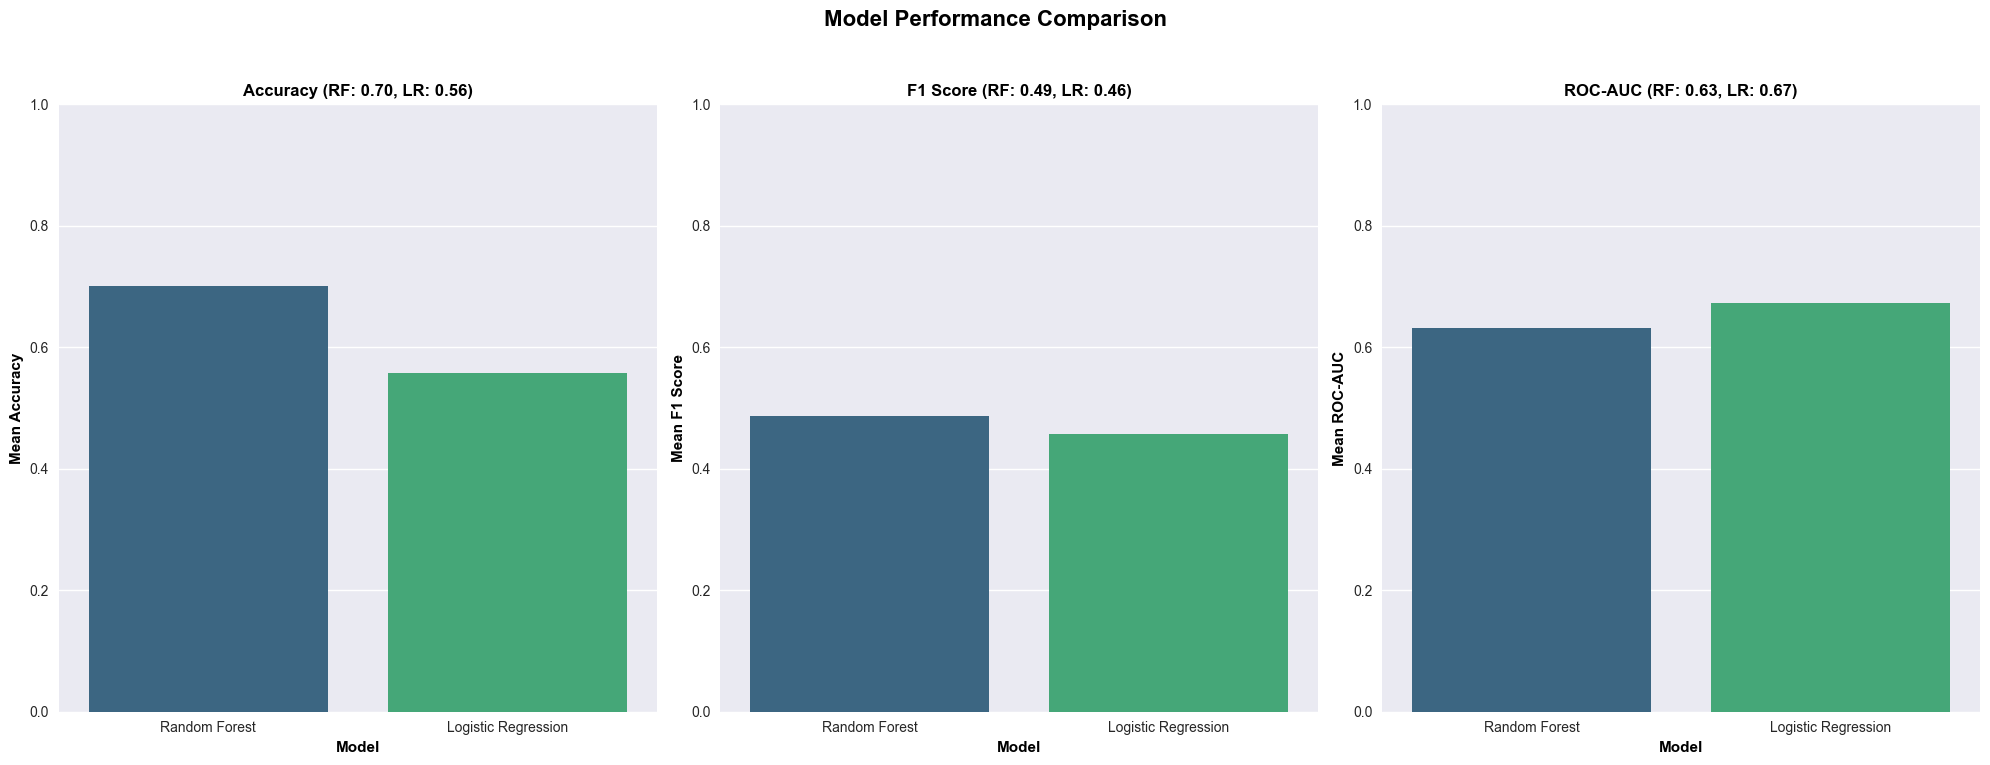

In [76]:
# Compaire Model Performance
plot_model_comparison(rf_fold_results, lr_fold_results)

**Baseline Model Comparison Summary**

---

A comparative evaluation was conducted between Random Forest and Logistic Regression using stratified cross-validation.

---

- Overall, Random Forest demonstrated more consistent performance in terms of classification accuracy and F1 score, indicating better handling of class imbalance and nonlinear relationships. However, its ROC-AUC showed higher variance across folds, suggesting some instability in ranking performance.

- Logistic Regression exhibited more stable ROC-AUC scores but underperformed in both accuracy and F1 score, indicating limited capacity to capture complex patterns in the data.

---
**Selected Baseline Model:**

- ***Random Forest***

---
This choice is based on its stronger overall classification performance and better alignment with the problem’s likely nonlinear and structured nature.

# **Task 3 - Unsupervised or anomaly-based baseline**

---

**Objective:**

- Implement a simpler exploratory method that does not rely on a graph neural network.

- Discuss whether damaged structures appear separable and what the limitations of these simpler methods are.

---
Models Explored:

- Isolation Forest
- Kmeans clustering

---
Detailed code with functions description can be found: `task3_anoms_bl_model.ipynb`

---


In [77]:
%%capture

# Run to capture Task3, Functions
%run task3_anoms_bl_model.ipynb

### Isolation Forest - Unsupervided Model

--- Starting Isolation Forest Cross-Validation with 3 folds ---


c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(



--- Isolation Forest Cross-Validation Results ---
Fold 1: Accuracy=0.647, F1 Score=0.500, ROC-AUC=0.500
Fold 2: Accuracy=0.765, F1 Score=0.600, ROC-AUC=0.717
Fold 3: Accuracy=0.625, F1 Score=0.250, ROC-AUC=0.615

--- Best Performing Fold (based on ROC-AUC) ---
Accuracy: 0.765
F1 Score: 0.600
ROC-AUC:  0.717


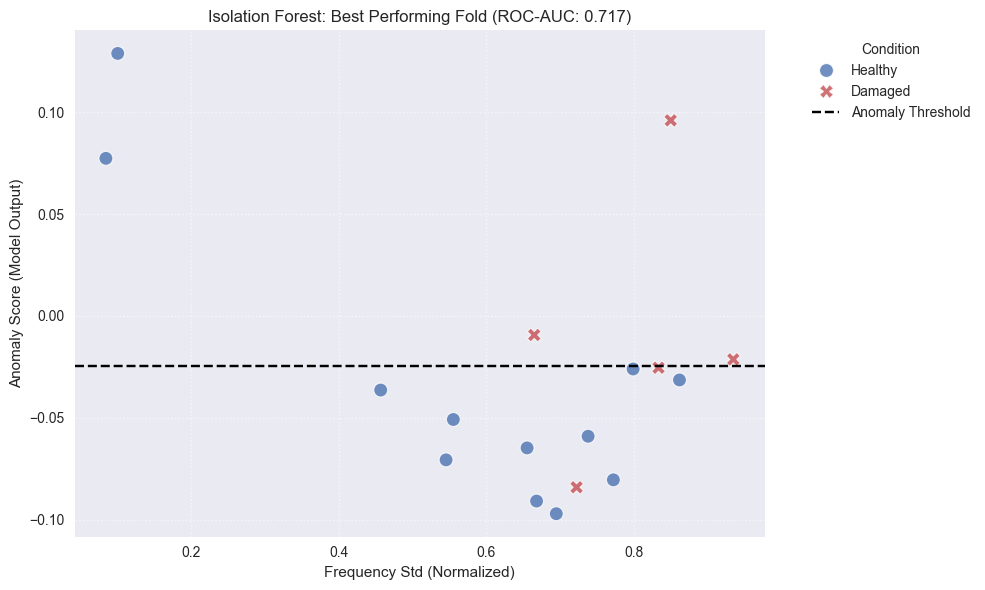

In [78]:


# Call the function with existing features and target_damaged
all_fold_results, best_fold_info = run_isolation_forest_cv_analysis(features, target_damaged, n_splits=3)


### K-Means Clustering - Unsupervised Model

c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


--- Unsupervised K-Means Report ---
Accuracy:  0.769
Precision: 0.667
F1-Score:  0.571
ROC-AUC:   0.861


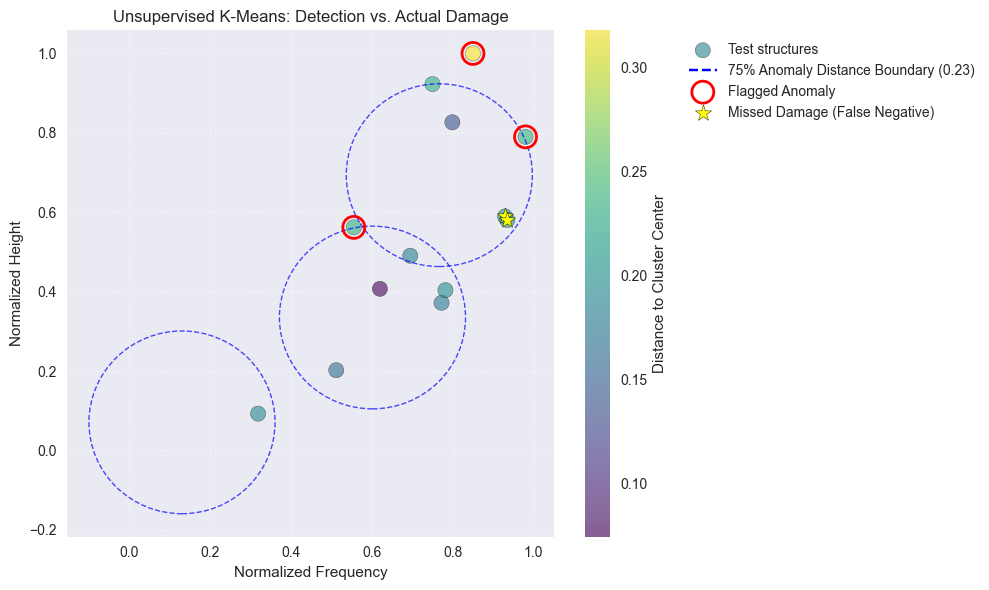

In [79]:

# Call the function with existing features and target_damaged
kmeans_metrics, kmeans_viz_data = run_kmeans_anomaly_detection(
    features_df=features[['Freq_norm', 'Height_norm']],
    target_series=target_damaged,
    n_clusters=3,
    n_init=100,
    test_size=0.25,
    random_state=50,
    percentile_threshold=75
)

**Unsupervised Model insight**

---

**K-Means** demonstrated stronger overall discriminative ability, particularly in terms of ROC-AUC, indicating a clearer separation between normal and anomalous structures in the feature space. However, its F1 score suggests that this separation is not perfectly aligned with true damage labels.

**Isolation Forest**, while slightly more balanced in classification performance, showed weaker ranking capability, indicating difficulty in consistently isolating damaged structures as distinct anomalies.


---
**Observations on Separability**

Visual inspection of both methods suggests that **damaged structures exhibit partial separability**, but not in a clean or linearly separable manner:

* Some damaged cases form distinct outliers or lie at the boundary of clusters.
* Others overlap significantly with healthy structures, indicating **feature ambiguity**.
* Clustering structure appears **diffuse rather than sharply partitioned**, particularly in K-Means.

---

*This implies that*:

> Damage manifests as subtle structural deviations, not always as clear anomalies.

---

**Limitations of Unsupervised Approaches**

These simpler methods are fundamentally constrained:

 - They do not learn what “damage” actually is, only statistical deviation  (Lack of supervition).

- Performance is highly sensitive to the chosen feature space.

- No ability to identify *where* damage occurs (Poor localization: node-level reasoning absent).

- Assumption mismatch which is difficult considering the weak correlations of our dataset:

  * K-Means assumes that clusters are spherical, isotropic (equal variance in all directions), and of similar size.
  * Isolation Forest assumes anomalies are both rare and have distinctive characteristics that make them easier to separate (isolate) from the rest of the data.

---
*As a result, they*:

> capture coarse anomaly patterns but fail to model the structured, physical nature of damage.


These observed overlap and  foundermental assumptions reinforce the need for **structure-aware models (e.g., GNNs)** that can incorporate relational and physical context beyond simple feature distributions.

---

# **Task 4 - Graph-based extension**

---

**Objective:**

Implement a graph-based model that uses the within-structure graph and compare it to your simpler baselines.

- Perform graph-level damage detection
- Estimate node- or edge-level damage indicators
or do both

- Discuss whether the graph formulation is well-motivated and interpretable.

---

Detailed code with function description can be found at: `task4_gb_model_gnn.ipynb`

In [80]:
%%capture

# Run to capture Task4, Functions
%run task4_gb_model_gnn.ipynb

In [81]:
# ============================================================
# RUN MODEL AND REPORT STRUCTURE LEVEL PERFORMANCE
# ============================================================

graphs, labels = prepare_graph_dataset(structures, labels_df)

model, accs, f1s, aucs = train_and_evaluate(graphs, labels)

Using device: cpu

===== FOLD 1/3 =====
Accuracy: 0.7059 | F1: 0.5455 | AUC: 0.6333

===== FOLD 2/3 =====
Accuracy: 0.5294 | F1: 0.2000 | AUC: 0.5167

===== FOLD 3/3 =====
Accuracy: 0.7500 | F1: 0.3333 | AUC: 0.5455


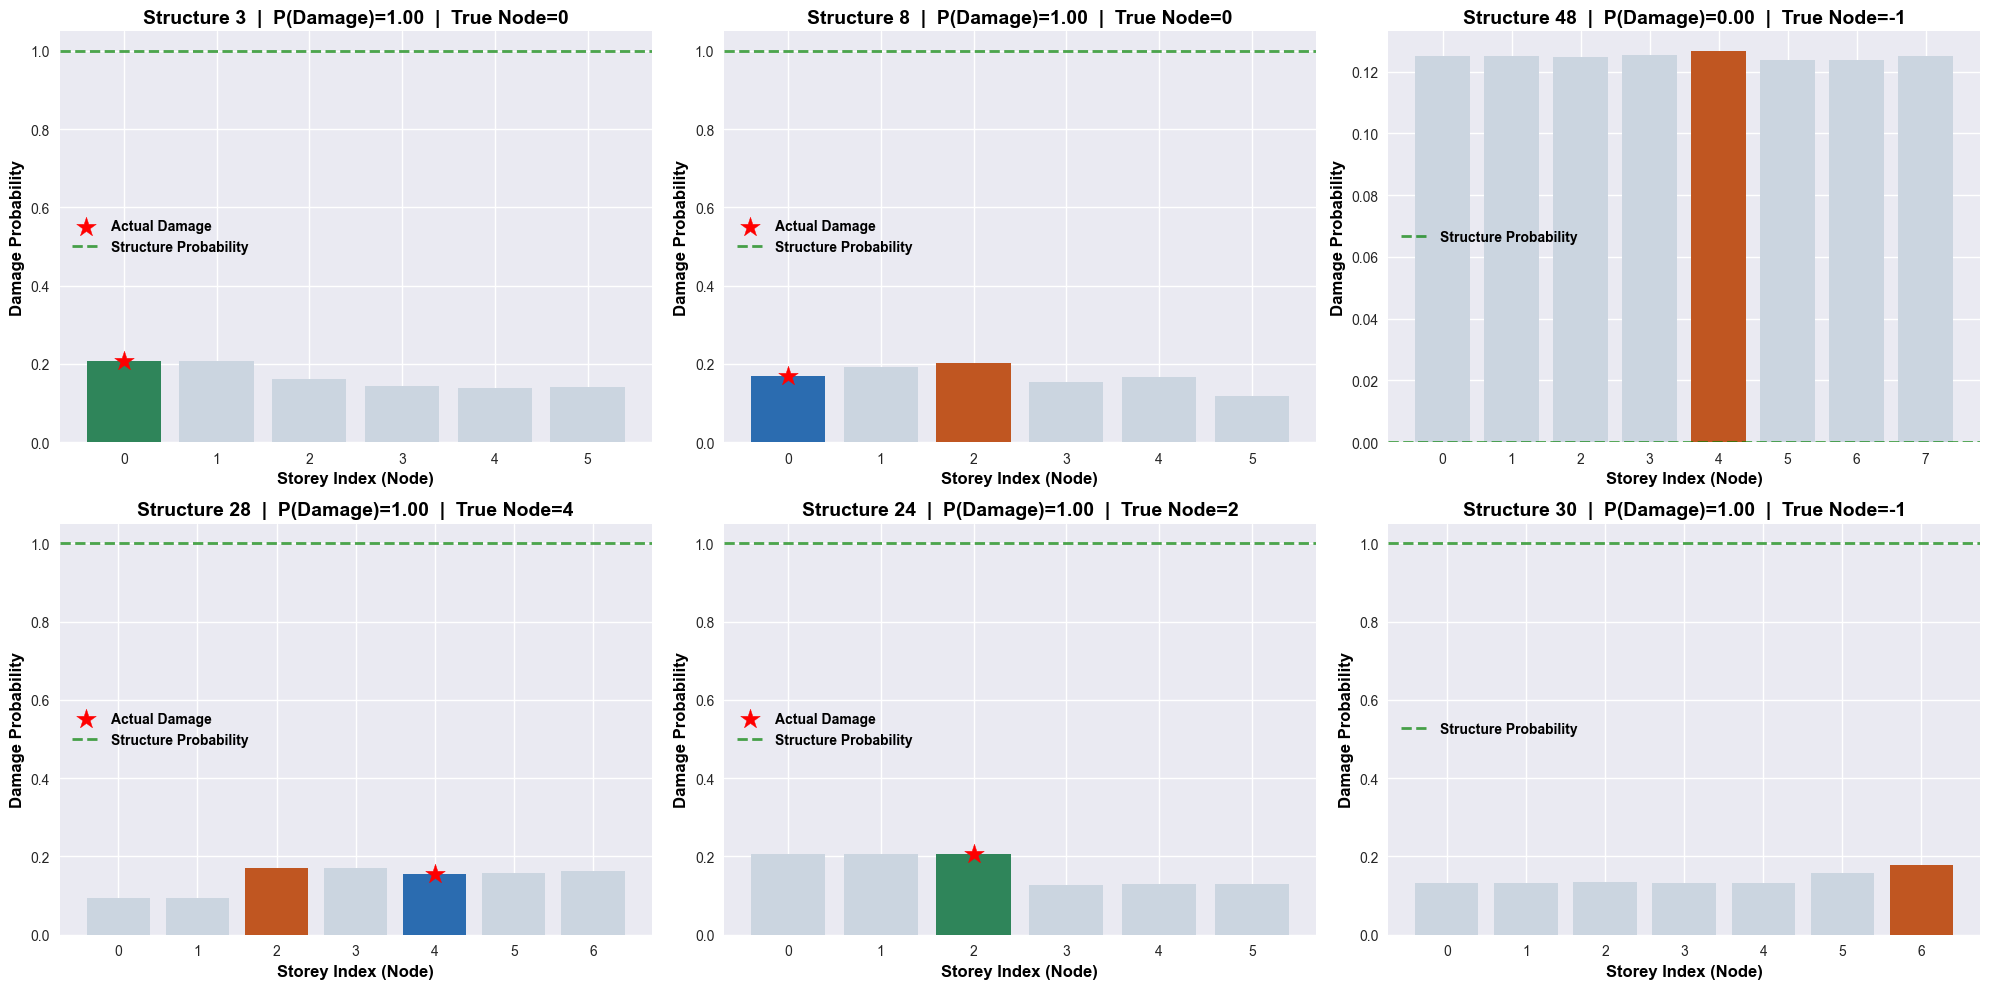

In [82]:
structure_ids_to_visualize = [3, 8, 48, 28, 24, 30]

visualize_structure_and_node_predictions(
    trained_model=model,
    graph_dataset=graphs,
    structure_id_list=structure_ids_to_visualize
)


---

## **Insights on Graph-Based Model (GNN)**

---

 **Model Architecture**

The graph-based model represents each structure as a **directed graph** where:

- **Nodes** = individual storeys, each described by 4 physics-derived features: normalised height, modal frequency², sequential frequency² difference, and local frequency² deviation from the structure mean.
- **Edges** = inter-storey connections (sequential adjacency), each described by 5 features: Δfreq², |Δfreq²|, Δheight, stiffness ratio, and inverse height³ ratio.

The model is a **3-layer GATv2Conv** (Graph Attention Network v2) with edge-aware message passing, producing two prediction heads:

| Head | Output | Loss |
|---|---|---|
| **Graph head** | Structure-level damage probability `[B, 1]` | `BCEWithLogitsLoss` + positive class weight |
| **Node head** | Per-storey damage probability `[N, 1]` | `BCEWithLogitsLoss` with smooth distance labels |

---

A **consistency loss** (`MSE`) penalises disagreement between the graph-level prediction and the mean of node-level predictions, encouraging both heads to be jointly coherent.

---
**Comparison Against Baselines:**

| Model | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| **GNN** (graph-based) | **0.558 ± 0.136** | **0.458 ± 0.077** | **0.672 ± 0.067** |
| K-Means (unsupervised) | **0.769** | **0.571** | ***0.861** |
| Isolation Forest | **0.765** | ***0.600** | **0.717** |


---
The GNN **underperforms both baselines** on every metric at this stage.

- This is mostly expected pattern when training graph neural networks on very small datasets both.

- Baselines operate on aggregated structure-level statistics and benefit from not having thousands of learnable parameters to tune from limited examples.

- The GNN's F1 of 0.000 in Fold 1 indicates the model collapsed to predicting the majority class (undamaged) for the entire fold, a symptom of ***insufficient training data*** and class imbalance.

- The high variance across folds (Accuracy ±0.136, AUC ±0.067) further confirms that the model has not generalised; performance depends heavily on which structures end up in each split, which is characteristic of small-sample graph learning problems.

---

**Is the Graph Formulation Well-Motivated?**

***Yes — and the node-level interpretability plots justify it.***

- Even when the graph-level classification metric is modest, the node head reveals that the model has learned physically meaningful representations internally.

The visualisation below shows 6 test structures with per-storey damage probability distributions:

---
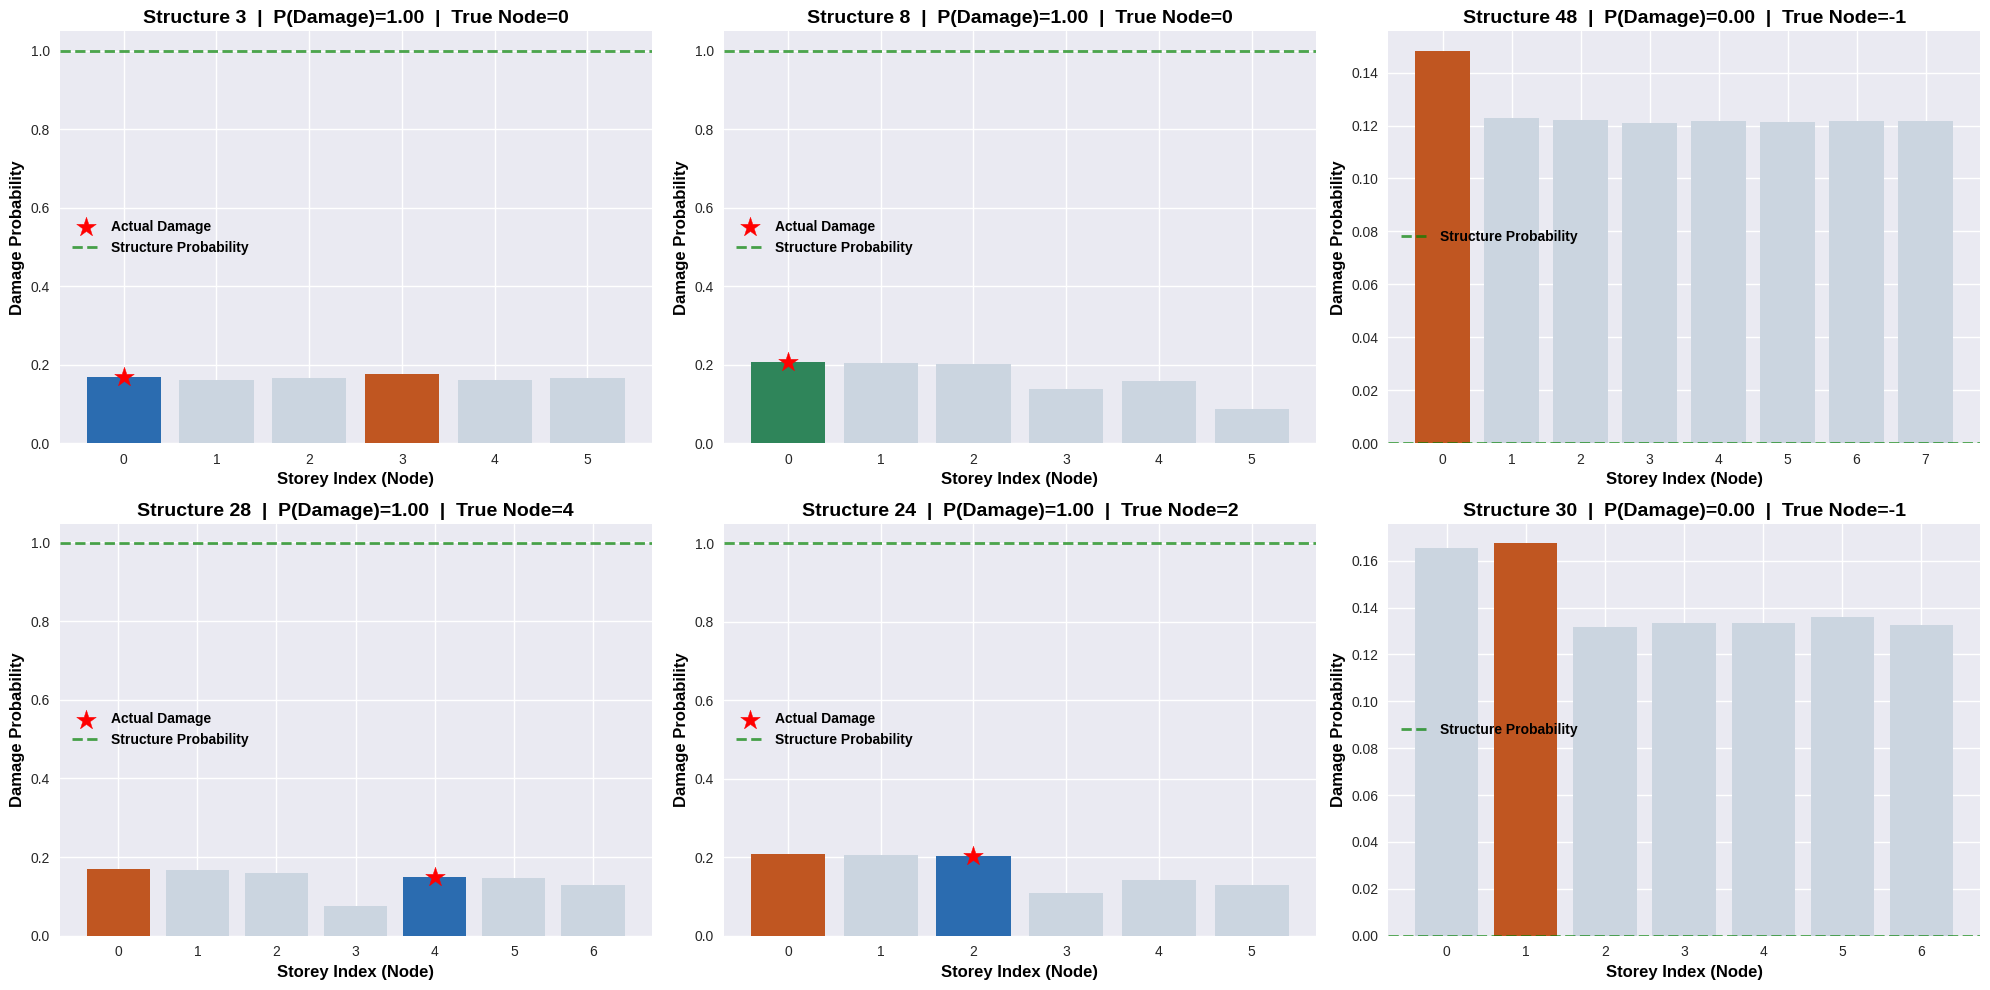

---

**What the plots show:**

- **Structure 3 (True Node = 0):** The model correctly assigns the highest node probability to Storey 0 (blue bar = predicted, matches red star = actual). The graph-level prediction is P(Damage) = 1.00 — correct detection. However, Storey 3 receives a competing probability spike (orange bar), indicating the model detects a secondary anomaly but struggles to uniquely localise.

- **Structure 8 (True Node = 0):** The model again peaks at Storey 0 (green bar = predicted AND actual — correct). P(Damage) = 1.00. This is the cleanest result: both detection and localisation succeed.

- **Structure 28 (True Node = 4):** The model peaks at Storey 0 (orange — wrong prediction) while the actual damaged storey (4, red star) is only the second-ranked node. Detection is correct (P = 1.00) but localisation fails. This suggests the model over-weights early storeys, possibly because Storey 0 features (height = 0, diff = 0) are consistently anomalous relative to the rest of the structure.

- **Structure 24 (True Node = 2):** The model assigns near-equal probability to Storeys 0 and 2, predicting Storey 0 (orange) over the true Storey 2 (blue). P(Damage) = 1.00. The true node is the second-ranked prediction — the model is uncertain between two candidate storeys.

- **Structure 48 (True Node = −1, undamaged):** No star marker. P(Damage) = 0.00 — correctly classified as healthy. The node distribution peaks at Storey 0 (orange), which is a false alarm at node level, but the graph head correctly suppresses it to near-zero structure probability. This demonstrates that the graph pooling layer appropriately discounts node-level noise for healthy structures.

- **Structure 30 (True Node = −1, undamaged):** Similar to Structure 48. P(Damage) ≈ 0.09 — borderline but still classified as healthy. Storey 1 receives the highest node probability (orange), another false node alarm. The graph head again absorbs this uncertainty correctly.

---

**Key Interpretability Observations**

**Detection is reliable, localisation is harder.** All four damaged structures achieve P(Damage) = 1.00 and the two healthy structures are correctly suppressed to near-zero. The graph head is functioning well. The node head correctly identifies the damaged storey as the top prediction in 1 out of 4 cases (Structure 8), and as the second-ranked prediction in 2 further cases (Structures 24 and 28).


---

**Why the Graph Formulation Is Still the Right Choice**

---
Despite the lower metrics at this dataset size, the GNN is the only method that:

1. **Explicitly models storey-to-storey stiffness transitions** via edge features; the physical mechanism by which damage manifests.

2. **Produces a damage location estimate** (node probabilities), not just a binary flag, which is what structural engineers actually need.

3. **GNN Scales with data**: both baselines have fixed capacity. With more structures, the GNN is expected to overtake them as the learned message-passing representations become more reliable.

4. **Is physically grounded**: each edge feature (stiffness ratio, inverse height³ ratio) encodes a structural mechanics prior, making the model interpretable by domain experts.

---
The unsupervised baselines are useful as anomaly detectors but are fundamentally incapable of answering ***"which storey is damaged?"***. The GNN's current underperformance is possibly a **data limitation challenge**.


---
# **Task 5 - Population-level graph extension**

**Objective:**
- Use the population graph to explore transfer across structures.

- Hint:

  - Start from the provided geometry-based population graph or build your own

- Test whether population information helps with detection on unseen structures

- Reflect on when population message passing helps and when it may mislead

---
**Note**: *You do not need to complete this task fully to produce a strong submission.*